# Data Drift Analysis — Credit Scoring Model

## Objectif
Simuler un scénario de drift réaliste en sélectionnant des sous-ensembles de données réelles qui représentent des changements de population.

## Données
- **Référence** : 200 000 lignes (`data/reference_data.parquet`) — échantillon représentatif de l'entraînement
- **Test** : 50 000 lignes (`data/test_data.parquet`) — validation
- **Pool de drift** : ~57K lignes (`data/drift_pool.parquet`) — source pour simuler des scénarios de production

## Scénarios de drift simulés
1. **Pas de drift** — échantillon aléatoire du pool (contrôle)
2. **Drift démographique** — uniquement les clients jeunes (< 35 ans)
3. **Drift économique** — uniquement les revenus élevés (> 300K)
4. **Drift crédit** — uniquement les crédits élevés (> 1M)

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("..") / "data"

reference = pd.read_parquet(data_dir / "reference_data.parquet")
test = pd.read_parquet(data_dir / "test_data.parquet")
drift_pool = pd.read_parquet(data_dir / "drift_pool.parquet")

print(f"Référence : {reference.shape}")
print(f"Test :      {test.shape}")
print(f"Pool :      {drift_pool.shape}")

Référence : (200000, 122)
Test :      (50000, 122)
Pool :      (57511, 122)


## Dataset Registry — Versionnement

In [15]:
import json

registry = json.loads((data_dir / "dataset_registry.json").read_text())
print(json.dumps(registry, indent=2))

{
  "version": "2.0",
  "creation_date": "2026-04-08",
  "source": "../project-6/data/application_train.csv",
  "total_source_rows": 307511,
  "datasets": {
    "reference_data.parquet": {
      "description": "Training reference for drift detection (random sample)",
      "rows": 200000,
      "columns": 122,
      "sha256": "a84c0627ffb2fc502b02f98b777487dd003d9a1f2a9966e44e3cb4610d092818",
      "random_state": 42
    },
    "test_data.parquet": {
      "description": "Test data for model validation (AUC comparison)",
      "rows": 50000,
      "columns": 122,
      "sha256": "d97ea2a6f5db42f304220bedd9b93f9628823f4e3f6376658ac1cefe8e5e7f9d",
      "random_state": 42
    },
    "drift_pool.parquet": {
      "description": "Remaining rows used as pool for drift simulation scenarios",
      "rows": 57511,
      "columns": 122,
      "sha256": "e7363342b0be34113dd67c8efce75794be9ef8c499f1a60306e8427a77466bc4",
      "random_state": null
    }
  }
}


## Scénario 0 : Pas de drift (contrôle)
Échantillon aléatoire du pool — devrait montrer peu ou pas de drift.

In [16]:
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

# Colonnes numériques communes pour l'analyse
num_cols = reference.select_dtypes(include=[np.number]).columns.tolist()
# Exclure SK_ID_CURR et TARGET si présents
exclude = ["SK_ID_CURR", "TARGET"]
num_cols = [c for c in num_cols if c not in exclude]

print(f"{len(num_cols)} features numériques analysées")

104 features numériques analysées


In [17]:
# Contrôle : échantillon aléatoire (pas de drift attendu)
no_drift_sample = drift_pool[num_cols].sample(n=5000, random_state=42)

report_control = Report(metrics=[DataDriftPreset()])
report_control.run(reference_data=reference[num_cols], current_data=no_drift_sample)

result = report_control.as_dict()
drift_info = result["metrics"][0]["result"]
print(f"Drift détecté : {drift_info['dataset_drift']}")
print(f"Features driftées : {drift_info['number_of_drifted_columns']} / {drift_info['number_of_columns']} ({drift_info['share_of_drifted_columns']:.1%})")

/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passke

Drift détecté : False
Features driftées : 0 / 104 (0.0%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


## Scénario 1 : Drift démographique
Sélection de clients jeunes uniquement (< 35 ans, soit DAYS_BIRTH > -12775).
Simule un changement de clientèle vers une population plus jeune.

In [18]:
# DAYS_BIRTH est négatif : -12775 jours ≈ 35 ans
young_clients = drift_pool[drift_pool["DAYS_BIRTH"] > -12775]
print(f"Clients jeunes (< 35 ans) : {len(young_clients)} / {len(drift_pool)} ({len(young_clients)/len(drift_pool):.1%})")

drift_young = young_clients[num_cols].sample(n=min(5000, len(young_clients)), random_state=42)

report_young = Report(metrics=[DataDriftPreset()])
report_young.run(reference_data=reference[num_cols], current_data=drift_young)

result_young = report_young.as_dict()
drift_info_young = result_young["metrics"][0]["result"]
print(f"\nDrift détecté : {drift_info_young['dataset_drift']}")
print(f"Features driftées : {drift_info_young['number_of_drifted_columns']} / {drift_info_young['number_of_columns']} ({drift_info_young['share_of_drifted_columns']:.1%})")

Clients jeunes (< 35 ans) : 15726 / 57511 (27.3%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passke


Drift détecté : False
Features driftées : 14 / 104 (13.5%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


In [19]:
# Détail des features driftées (drift_by_columns est dans metrics[1])
drift_detail_young = result_young["metrics"][1]["result"]["drift_by_columns"]

drifted_young = []
for col, info in drift_detail_young.items():
    if info["drift_detected"]:
        drifted_young.append({"feature": col, "score": round(info["drift_score"], 4), "test": info["stattest_name"]})

df_drifted_young = pd.DataFrame(drifted_young).sort_values("score", ascending=False)
print(f"Top 15 features driftées (jeunes) :")
df_drifted_young.head(15)

Top 15 features driftées (jeunes) :


,feature,score,test
4,DAYS_BIRTH,1.2204,Wasserstein distance (normed)
9,EXT_SOURCE_1,0.6376,Wasserstein distance (normed)
5,DAYS_EMPLOYED,0.4607,Wasserstein distance (normed)
8,DAYS_REGISTRATION,0.3812,Wasserstein distance (normed)
6,DAYS_ID_PUBLISH,0.3634,Wasserstein distance (normed)
11,EXT_SOURCE_3,0.3011,Wasserstein distance (normed)
2,CNT_CHILDREN,0.2673,Wasserstein distance (normed)
13,FLAG_EMP_PHONE,0.2421,Jensen-Shannon distance
0,AMT_CREDIT,0.2177,Wasserstein distance (normed)
1,AMT_GOODS_PRICE,0.2161,Wasserstein distance (normed)


## Scénario 2 : Drift économique
Sélection de clients à revenus élevés (> 300K).
Simule un changement vers une clientèle plus aisée.

In [20]:
high_income = drift_pool[drift_pool["AMT_INCOME_TOTAL"] > 300000]
print(f"Clients revenus > 300K : {len(high_income)} / {len(drift_pool)} ({len(high_income)/len(drift_pool):.1%})")

drift_income = high_income[num_cols].sample(n=min(5000, len(high_income)), random_state=42)

report_income = Report(metrics=[DataDriftPreset()])
report_income.run(reference_data=reference[num_cols], current_data=drift_income)

result_income = report_income.as_dict()
drift_info_income = result_income["metrics"][0]["result"]
print(f"\nDrift détecté : {drift_info_income['dataset_drift']}")
print(f"Features driftées : {drift_info_income['number_of_drifted_columns']} / {drift_info_income['number_of_columns']} ({drift_info_income['share_of_drifted_columns']:.1%})")

Clients revenus > 300K : 4358 / 57511 (7.6%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passke


Drift détecté : True
Features driftées : 52 / 104 (50.0%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passke

In [21]:
drift_detail_income = result_income["metrics"][1]["result"]["drift_by_columns"]

drifted_income = []
for col, info in drift_detail_income.items():
    if info["drift_detected"]:
        drifted_income.append({"feature": col, "score": round(info["drift_score"], 4), "test": info["stattest_name"]})

df_drifted_income = pd.DataFrame(drifted_income).sort_values("score", ascending=False)
print(f"Top 15 features driftées (revenus élevés) :")
df_drifted_income.head(15)

Top 15 features driftées (revenus élevés) :


,feature,score,test
0,AMT_ANNUITY,1.0986,Wasserstein distance (normed)
2,AMT_GOODS_PRICE,0.9471,Wasserstein distance (normed)
1,AMT_CREDIT,0.9216,Wasserstein distance (normed)
3,AMT_INCOME_TOTAL,0.8387,Wasserstein distance (normed)
44,REGION_POPULATION_RELATIVE,0.5671,Wasserstein distance (normed)
27,FLOORSMAX_AVG,0.4387,Wasserstein distance (normed)
28,FLOORSMAX_MEDI,0.4325,Wasserstein distance (normed)
29,FLOORSMAX_MODE,0.4109,Wasserstein distance (normed)
19,ELEVATORS_AVG,0.3762,Wasserstein distance (normed)
20,ELEVATORS_MEDI,0.3657,Wasserstein distance (normed)


## Scénario 3 : Drift crédit
Sélection de crédits élevés (> 1M).
Simule un afflux de demandes de prêts importants.

In [22]:
high_credit = drift_pool[drift_pool["AMT_CREDIT"] > 1000000]
print(f"Crédits > 1M : {len(high_credit)} / {len(drift_pool)} ({len(high_credit)/len(drift_pool):.1%})")

drift_credit = high_credit[num_cols].sample(n=min(5000, len(high_credit)), random_state=42)

report_credit = Report(metrics=[DataDriftPreset()])
report_credit.run(reference_data=reference[num_cols], current_data=drift_credit)

result_credit = report_credit.as_dict()
drift_info_credit = result_credit["metrics"][0]["result"]
print(f"\nDrift détecté : {drift_info_credit['dataset_drift']}")
print(f"Features driftées : {drift_info_credit['number_of_drifted_columns']} / {drift_info_credit['number_of_columns']} ({drift_info_credit['share_of_drifted_columns']:.1%})")

Crédits > 1M : 9390 / 57511 (16.3%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passke


Drift détecté : False
Features driftées : 17 / 104 (16.3%)


/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/passkey1510/workspace/data-scientist-ocr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


## Comparaison des scénarios

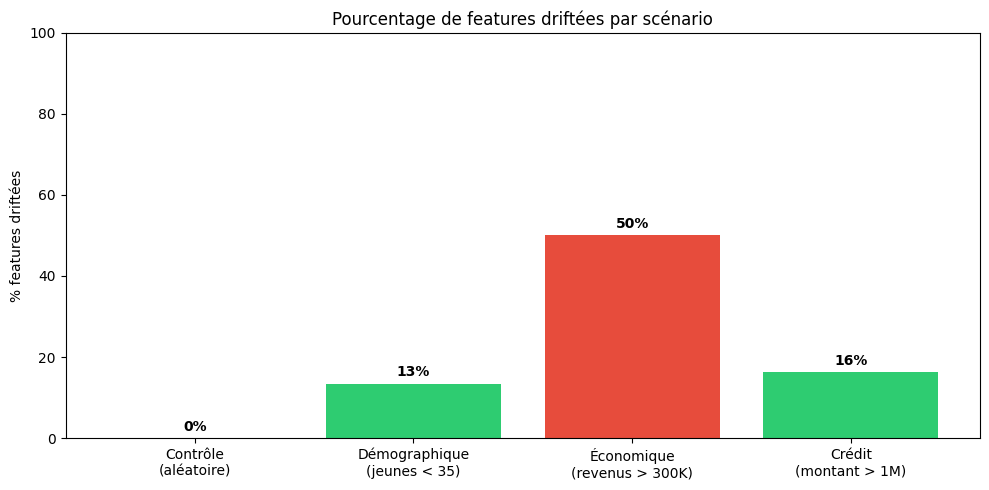

In [23]:
import matplotlib.pyplot as plt

scenarios = ["Contrôle\n(aléatoire)", "Démographique\n(jeunes < 35)", "Économique\n(revenus > 300K)", "Crédit\n(montant > 1M)"]
drift_shares = [
    drift_info["share_of_drifted_columns"],
    drift_info_young["share_of_drifted_columns"],
    drift_info_income["share_of_drifted_columns"],
    drift_info_credit["share_of_drifted_columns"],
]
drift_detected = [
    drift_info["dataset_drift"],
    drift_info_young["dataset_drift"],
    drift_info_income["dataset_drift"],
    drift_info_credit["dataset_drift"],
]
colors = ["#2ecc71" if not d else "#e74c3c" for d in drift_detected]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(scenarios, [s * 100 for s in drift_shares], color=colors)
for bar, s in zip(bars, drift_shares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{s:.0%}",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("% features driftées")
ax.set_title("Pourcentage de features driftées par scénario")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Visualisation : distributions avant/après drift

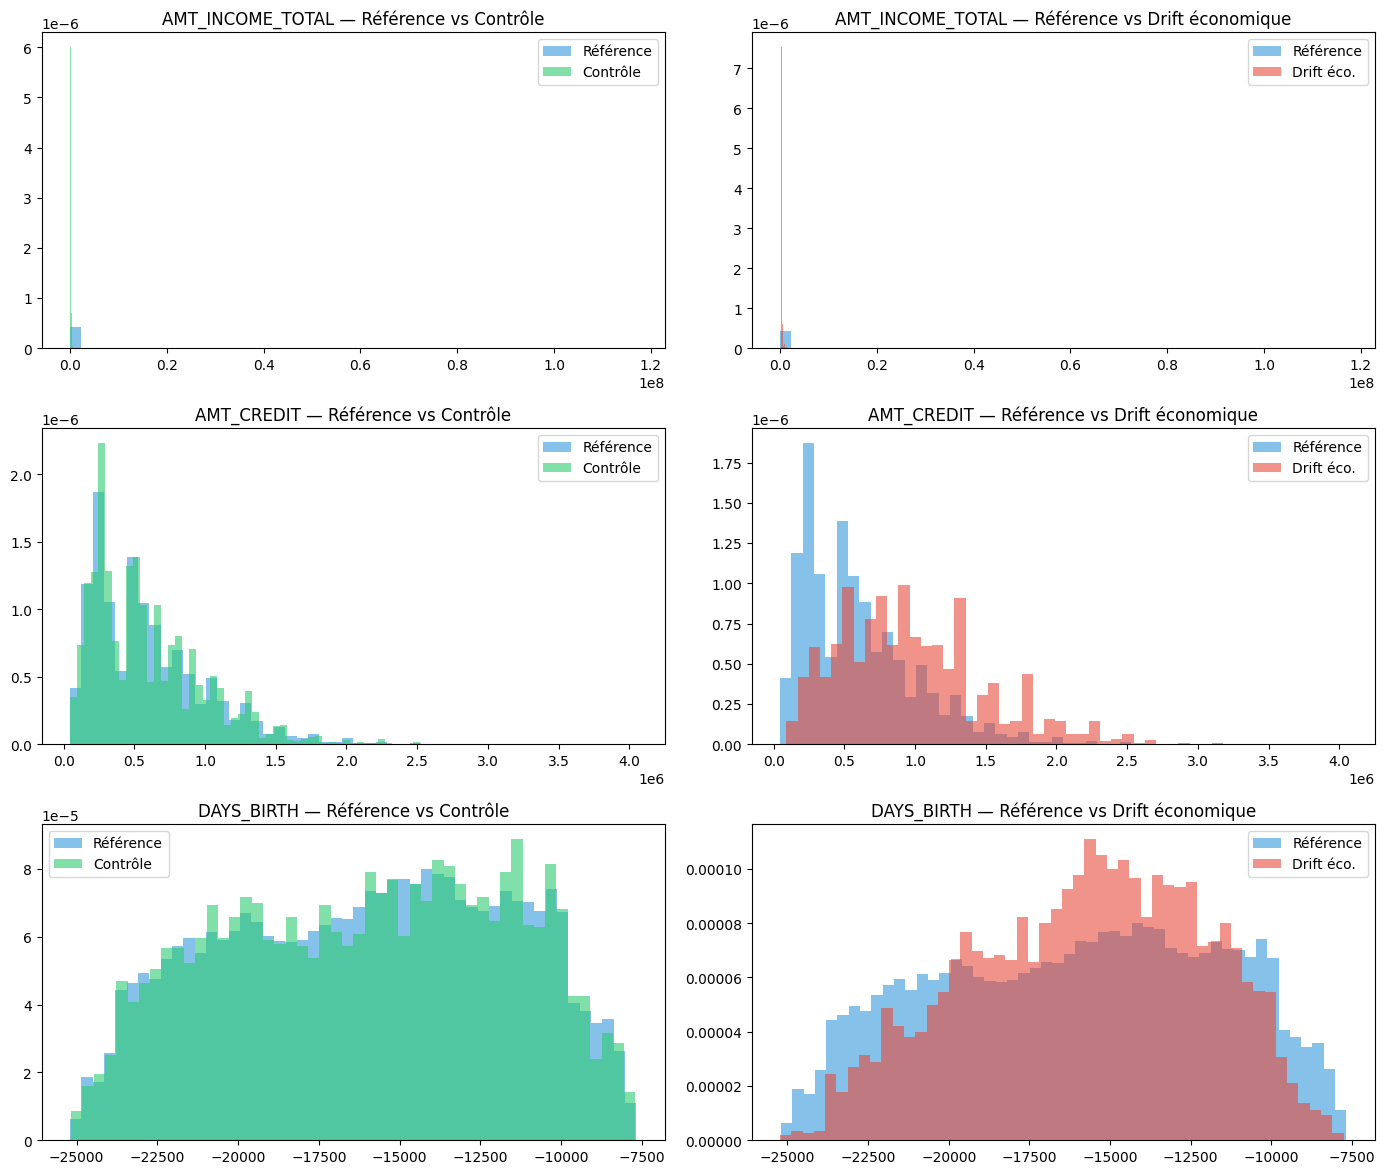

In [24]:
key_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "DAYS_BIRTH"]

fig, axes = plt.subplots(len(key_features), 2, figsize=(14, 4 * len(key_features)))

for i, feat in enumerate(key_features):
    # Left: reference vs control
    axes[i, 0].hist(reference[feat].dropna(), bins=50, alpha=0.6, color="#3498db", label="Référence", density=True)
    if feat in no_drift_sample.columns:
        axes[i, 0].hist(no_drift_sample[feat].dropna(), bins=50, alpha=0.6, color="#2ecc71", label="Contrôle", density=True)
    axes[i, 0].set_title(f"{feat} — Référence vs Contrôle")
    axes[i, 0].legend()

    # Right: reference vs drift économique
    axes[i, 1].hist(reference[feat].dropna(), bins=50, alpha=0.6, color="#3498db", label="Référence", density=True)
    if feat in drift_income.columns:
        axes[i, 1].hist(drift_income[feat].dropna(), bins=50, alpha=0.6, color="#e74c3c", label="Drift éco.", density=True)
    axes[i, 1].set_title(f"{feat} — Référence vs Drift économique")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## Pipeline de réentraînement automatisé

Quand un drift est détecté, le pipeline `pipeline/retrain.py` :

1. **Détecte le drift** (Evidently AI)
2. **Réentraîne** un modèle candidat sur les nouvelles données
3. **Valide** le candidat vs le champion sur le jeu de test
4. **Gate humaine** — écrit `pending_approval.json`, attend validation
5. **Déploiement** via `pipeline/approve.py` après approbation humaine

```
python pipeline/retrain.py --production-data data/drift_scenario.parquet
python pipeline/approve.py  # après validation humaine
```

In [ ]:
# Sauvegarder un scénario de drift pour tester le pipeline
# On inclut SK_ID_CURR et TARGET pour que le pipeline puisse matcher les labels
export_cols = num_cols + ["SK_ID_CURR", "TARGET"]
export_cols = [c for c in export_cols if c in high_income.columns]
drift_export = high_income[export_cols].sample(n=min(5000, len(high_income)), random_state=42)
drift_export.to_parquet(data_dir / "production_sample.parquet", index=False)
print(f"Scénario de drift économique sauvegardé : {drift_export.shape}")
print(f"Colonnes incluses : {drift_export.shape[1]} (dont SK_ID_CURR et TARGET)")
print("\nPour tester le pipeline :")
print("  python pipeline/retrain.py")
print("  python pipeline/approve.py")

## Sauvegarde des rapports HTML

In [26]:
report_control.save_html("drift_report_control.html")
report_young.save_html("drift_report_young.html")
report_income.save_html("drift_report_income.html")
report_credit.save_html("drift_report_credit.html")
print("4 rapports HTML sauvegardés")

4 rapports HTML sauvegardés


## Conclusions

| Scénario | Drift détecté | Features driftées | Interprétation |
|----------|--------------|-------------------|----------------|
| Contrôle (aléatoire) | Non (0.0%) | 0/104 | Échantillon i.i.d. — aucun drift, baseline confirmé |
| Démographique (< 35 ans) | Non (13.5%) | 14/104 | Drift visible sur l'âge et l'emploi, mais sous le seuil Evidently (50%) |
| Économique (> 300K) | **Oui (50.0%)** | 52/104 | Revenus, montants, ratios financiers tous impactés — atteint le seuil |
| Crédit (> 1M) | Non (16.3%) | 17/104 | Drift modéré, sous le seuil de 50% |

### Comment Evidently détecte le drift
1. **Par feature** : test statistique (Wasserstein distance pour les numériques, Jensen-Shannon pour les catégorielles). Si p-value < 0.05 → la feature est considérée driftée.
2. **Au niveau dataset** : si plus de **50% des features** sont driftées → `dataset_drift = True` (seuil par défaut d'Evidently).

### Recommandations
- **Monitoring continu** : exécuter ce rapport quotidiennement/hebdomadairement en production
- **Réentraînement** : déclenché automatiquement quand Evidently signale `dataset_drift = True`
- **Human-in-the-loop** : le modèle candidat doit être validé par un expert avant déploiement
- **Versionnement** : chaque dataset et modèle est versionné dans `dataset_registry.json`